In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np
import ast
import math
from table_generator import aggregate_across_seeds, load_results_dataframe, flatten_config, diagnose_grouping_conflicts, get_best_runs_by_val_f1_macro

# Rebuild matplotlib font cache to detect newly installed fonts (CMU Serif)
fm._load_fontmanager(try_read_cache=False)
print("Font cache rebuilt. CMU Serif available:", "CMU Serif" in [f.name for f in fm.fontManager.ttflist])

Font cache rebuilt. CMU Serif available: True


In [15]:
wandb_username = "bioshape-lab"  # W&B username/entity
wandb_project = "bgbench_multi_dataset_grid_search_readout_rest"  # W&B project name
csv_filename = "final_results_hyperparams.csv"  # Output CSV filename


df = load_results_dataframe(
    wandb_username,
    wandb_project,
    csv_filename=csv_filename,
    force_load=False,
    save_csv=True,
)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/lcornelis/.netrc.
/home/lcornelis/code/bgbench-1/tutorials/table_generator.py:147: DtypeWarning: Columns (63,69,70,89,98,107,108,109,110,117,123,154,162,164,170,171,179,181,185,192,195,198,201,224,225,229,234,237,238,239,242,244,245,246) have mixed types. Specify dtype option on import or set low_memory=False.
  df_existing = pd.read_csv(csv_filename)


▶ Found existing CSV with 59294 runs
▶ Found 3165 new runs in W&B
▶ Scanning runs to find new ones (checking IDs only, fast)...


Scanning for new runs:   0%|          | 100/62459 [00:04<44:41, 23.26run/s]


KeyboardInterrupt: 

In [16]:
csv_filename = "final_results_hyperparams.csv" 
df = pd.read_csv(csv_filename)
aggregated_df = aggregate_across_seeds(
    df,             # auto-detects
    metric_prefix="summary.",
    output_filename="aggregated_results.csv",
)

print(aggregated_df.shape)
aggregated_df.head()

/tmp/ipykernel_3136821/3967649953.py:2: DtypeWarning: Columns (63,69,70,89,98,107,108,109,110,117,123,154,162,164,170,171,179,181,185,192,195,198,201,224,225,229,234,237,238,239,242,244,245,246) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_filename)


▶ Using seed column: seed
▶ Found 57 metric columns with prefix 'summary.'
▶ Initial grouping candidates (after dropping bad cols): 185
▶ Final grouping columns (after nunique filter): 185
▶ Numeric metric columns kept: 56
▶ Dropped 1 all-NaN / non-numeric metric columns (e.g.): ['summary.checkpoint']
▶ Filtering: 783 groups removed (did not have exactly 3 seeds)
▶ Keeping: 18246 groups with exactly 3 seeds


/home/lcornelis/code/bgbench-1/tutorials/table_generator.py:549: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_group_filtered = df_group.set_index(grouping_cols).loc[groups_with_3_seeds].reset_index()
/home/lcornelis/code/bgbench-1/tutorials/table_generator.py:549: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_group_filtered = df_group.set_index(grouping_cols).loc[groups_with_3_seeds].reset_index()
/home/lcornelis/code/bgbench-1/tutorials/table_generator.py:549: PerformanceWarning: DataFrame is highly fragmented.  This is 

▶ Aggregated shape: (18246, 353)
▶ Number of unique experiment configurations: 18246
▶ Saved aggregated results to: aggregated_results.csv
(18246, 353)


,loss._target_,loss.dataset_loss.task,loss.dataset_loss.loss_type,loss.dataset_loss.class_weights,loss.modules_losses.readout,loss.modules_losses.backbone,loss.modules_losses.feature_encoder,tags,test,model.compile,...,summary.val/f1_weighted_count,summary.val/loss,summary.val/loss_std,summary.val/loss_count,summary.val/precision,summary.val/precision_std,summary.val/precision_count,summary.val/recall,summary.val/recall_std,summary.val/recall_count
0,__val__:'ogbench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,__NaN__,"__val__:""['omics_readout', 'sage', 'parkinsons...",__val__:True,__val__:False,...,3,0.716205,0.199433,3,0.716134,0.009332,3,0.661818,0.016664,3
1,__val__:'ogbench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,__NaN__,"__val__:""['omics_readout', 'sage', 'parkinsons...",__val__:True,__val__:False,...,3,0.668792,0.111471,3,0.436156,0.160052,3,0.532727,0.056685,3
2,__val__:'ogbench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,__NaN__,"__val__:""['omics_readout', 'sage', 'parkinsons...",__val__:True,__val__:False,...,3,1.033895,0.065559,3,0.672486,0.039904,3,0.633333,0.019441,3
3,__val__:'ogbench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,__NaN__,"__val__:""['omics_readout', 'sage', 'parkinsons...",__val__:True,__val__:False,...,3,0.960883,0.213093,3,0.558465,0.186162,3,0.584242,0.075893,3
4,__val__:'ogbench.loss.TBLoss',__val__:'classification',__val__:'cross_entropy',__NaN__,__NaN__,__NaN__,__NaN__,"__val__:""['omics_readout', 'sage', 'parkinsons...",__val__:True,__val__:False,...,3,1.069859,0.300864,3,0.684009,0.007388,3,0.661212,0.033146,3


In [29]:
# ------------------------------------------------------------------
# Create consistent color mapping for all models
# This ensures all plots use the same colors for the same models
# ------------------------------------------------------------------
import ast

# Helper function to decode serialized values
def _decode_val(x):
    """Decode serialized values like "__val__:'sagn'" -> "sagn"."""
    if isinstance(x, str):
        if x == "__NaN__":
            return np.nan
        if x.startswith("__val__:"):
            inner = x[len("__val__:"):]
            # Strip simple quotes if present
            if inner.startswith("'") and inner.endswith("'"):
                return inner[1:-1]
            # Try to literal-eval numbers / booleans
            try:
                return ast.literal_eval(inner)
            except Exception:
                return inner
    return x

# Get all unique models from the aggregated data
model_col = "model.model_name"
df_temp = aggregated_df.copy()

# Decode serialized values for the model column
if model_col in df_temp.columns:
    df_temp[model_col] = df_temp[model_col].apply(_decode_val)

# Get all unique models and sort them
all_models = sorted(df_temp[model_col].dropna().unique().tolist())

# Create a consistent color mapping for all models
# Assign distinct colors to mlp, gatv4, and sagn
# Use a consistent color family for the remaining models (gatv2, sage, etc.)
shared_model_colors_dict = {}

# Models that should have distinct colors - using aesthetically pleasing colors
distinct_models = {
    'mlp': '#E63946',      # Vibrant coral red - distinct color for MLP
    'gatv4': '#06A77D',    # Rich teal green - distinct color for GATv4
    'sagn': '#F77F00',     # Warm orange - distinct color for SAGN
}

# Get remaining models (excluding the distinct ones)
remaining_models = [m for m in all_models if m.lower() not in [k.lower() for k in distinct_models.keys()]]
remaining_models = sorted(remaining_models)

# Use a cohesive color palette for related models (blues/purples family)
# This creates a visually harmonious group for gatv2, sage, etc.
related_color_palette = [
    '#457B9D',  # Soft blue
    '#6C5CE7',  # Purple-blue
    '#A29BFE',  # Light purple
    '#74B9FF',  # Sky blue
    '#0984E3',  # Deep blue
    '#5F27CD',  # Deep purple
]

# Assign distinct colors to mlp, gatv4, and sagn
for model in all_models:
    model_lower = model.lower()
    if model_lower in distinct_models:
        shared_model_colors_dict[model] = distinct_models[model_lower]
    else:
        # Use a consistent color family for remaining models
        # Find the index of this model in the remaining models list
        idx = remaining_models.index(model)
        # Cycle through the related color palette
        shared_model_colors_dict[model] = related_color_palette[idx % len(related_color_palette)]

print(f"Created color mapping for {len(all_models)} models:")
print("\nDistinct colors:")
for model in all_models:
    model_lower = model.lower()
    if model_lower in distinct_models:
        print(f"  {model}: {shared_model_colors_dict[model]}")
print("\nRelated models (same color family):")
for model in remaining_models:
    print(f"  {model}: {shared_model_colors_dict[model]}")



Created color mapping for 5 models:

Distinct colors:
  GATv4: #06A77D
  mlp: #E63946
  sagn: #F77F00

Related models (same color family):
  gatv2: #457B9D
  sage: #6C5CE7


In [30]:
# ------------------------------------------------------------------
# Get best runs by val/f1_macro per dataset, method, and node_sample_ratio
# ------------------------------------------------------------------
best_runs_tables = get_best_runs_by_val_f1_macro(
    aggregated_df,
    metric_col="summary.val/f1_macro",
    datasets=["motrpac", "addneuromed", "parkinsons"]
)

# Display tables for each dataset (mean ± std)
for dataset_name, table in best_runs_tables.items():
    print(f"\n{'='*80}")
    print(f"Best val/f1_macro (mean ± std) for {dataset_name.upper()}")
    print(f"{'='*80}")
    print(table.to_string())
    print()



Best val/f1_macro (mean ± std) for MOTRPAC
dataset.loader.parameters.node_sample_ratio              0.3              0.5              0.8              1.0
dataset.loader.parameters.method                                                                               
correlation                                  0.6076 ± 0.0045  0.6124 ± 0.0156  0.6256 ± 0.0079  0.6211 ± 0.0038
distance_correlation                         0.6123 ± 0.0034  0.6047 ± 0.0114  0.6175 ± 0.0045  0.6161 ± 0.0134
random                                       0.5992 ± 0.0115  0.5927 ± 0.0275  0.5950 ± 0.0256  0.6047 ± 0.0105
variance                                     0.6052 ± 0.0043  0.6062 ± 0.0166  0.6140 ± 0.0227  0.5860 ± 0.0656


Best val/f1_macro (mean ± std) for ADDNEUROMED
dataset.loader.parameters.node_sample_ratio              0.3              0.5              0.8              1.0
dataset.loader.parameters.method                                                                               
correlation

/home/lcornelis/code/bgbench-1/tutorials/table_generator.py:836: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6076 ± 0.0045' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  combined_table.loc[idx, col] = f"{mean_val:.4f} ± {std_val:.4f}"
/home/lcornelis/code/bgbench-1/tutorials/table_generator.py:836: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6124 ± 0.0156' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  combined_table.loc[idx, col] = f"{mean_val:.4f} ± {std_val:.4f}"
/home/lcornelis/code/bgbench-1/tutorials/table_generator.py:836: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6256 ± 0.0079' has dtype incompatible with float64, please explicitly 

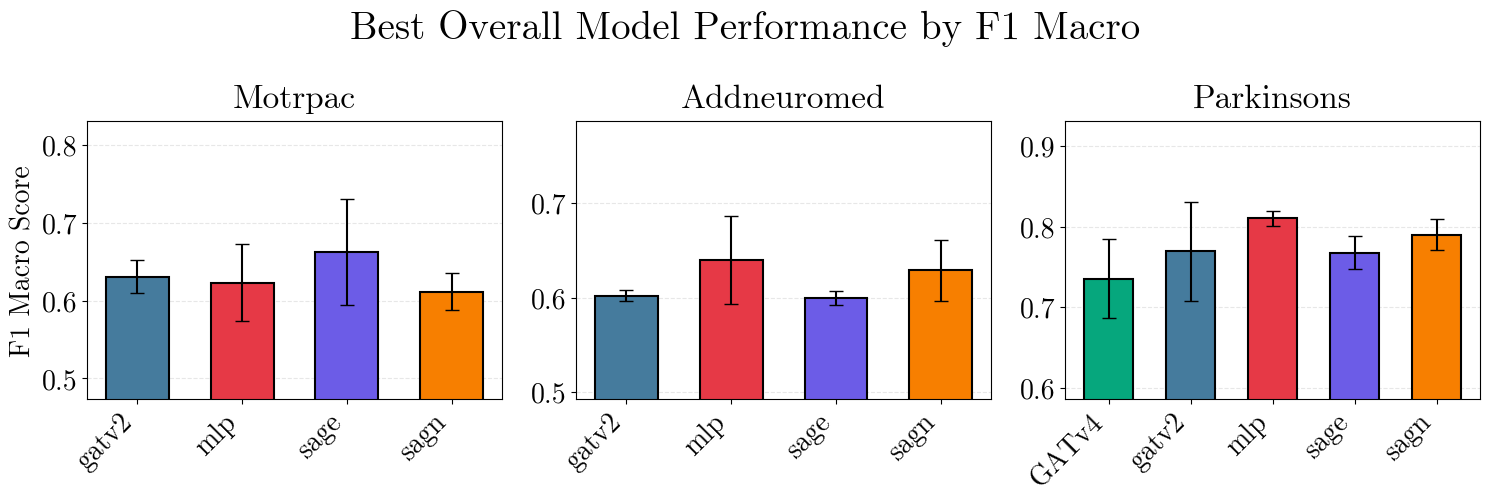


Best Performance by Model and Dataset:

GATv4:
  motrpac: No data
  addneuromed: No data
  parkinsons: 0.7353 ± 0.0491

gatv2:
  motrpac: 0.6307 ± 0.0207
  addneuromed: 0.6020 ± 0.0059
  parkinsons: 0.7692 ± 0.0611

mlp:
  motrpac: 0.6228 ± 0.0496
  addneuromed: 0.6397 ± 0.0467
  parkinsons: 0.8104 ± 0.0095

sage:
  motrpac: 0.6622 ± 0.0679
  addneuromed: 0.5998 ± 0.0074
  parkinsons: 0.7675 ± 0.0205

sagn:
  motrpac: 0.6115 ± 0.0232
  addneuromed: 0.6289 ± 0.0321
  parkinsons: 0.7901 ± 0.0192


In [46]:
# ------------------------------------------------------------------
# Plot: Best Overall Model Performance by F1 Macro
# ------------------------------------------------------------------
# Set font to CMU Serif
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['CMU Serif']

# Read from aggregated_results.csv and filter for each dataset and model
# Rows: Models (from model.model_name)
# Columns: Datasets
# Each subplot: Best performance for that model-dataset combination
metric_col = "summary.best_test/f1_macro"
metric_std_col = f"{metric_col}_std"
data_name_col = "dataset.loader.parameters.data_name"
method_col = "model.model_name"

# Helper function to decode serialized values
def _decode_val(x):
    """Decode serialized values like "__val__:'sagn'" -> "sagn"."""
    if isinstance(x, str):
        if x == "__NaN__":
            return np.nan
        if x.startswith("__val__:"):
            inner = x[len("__val__:"):]
            # Strip simple quotes if present
            if inner.startswith("'") and inner.endswith("'"):
                return inner[1:-1]
            # Try to literal-eval numbers / booleans
            try:
                return ast.literal_eval(inner)
            except Exception:
                return inner
    return x

# Load aggregated data
df_plot = aggregated_df.copy()

# Decode serialized values for the grouping columns
for col in [data_name_col, method_col]:
    if col in df_plot.columns:
        df_plot[col] = df_plot[col].apply(_decode_val)

# Ensure metrics are numeric
df_plot[metric_col] = pd.to_numeric(df_plot[metric_col], errors="coerce")
df_plot[metric_std_col] = pd.to_numeric(df_plot[metric_std_col], errors="coerce")

# Filter to valid data and the three datasets
df_plot = df_plot.dropna(subset=[data_name_col, method_col, metric_col])
df_plot = df_plot[df_plot[data_name_col].isin(["motrpac", "addneuromed", "parkinsons"])]

# Get all unique models and datasets
all_models = sorted(df_plot[method_col].dropna().unique().tolist())
datasets = ["motrpac", "addneuromed", "parkinsons"]  # Keep consistent order

# For each model-dataset combination, find the best performance
plot_data = {}
for model in all_models:
    plot_data[model] = {}
    for dataset in datasets:
        # Filter for this model-dataset combination
        subset = df_plot[
            (df_plot[method_col] == model) &
            (df_plot[data_name_col] == dataset)
        ]
        
        if len(subset) > 0:
            # Find the best performance for this combination
            best_idx = subset[metric_col].idxmax()
            plot_data[model][dataset] = {
                'mean': subset.loc[best_idx, metric_col],
                'std': subset.loc[best_idx, metric_std_col]
            }
        else:
            plot_data[model][dataset] = {'mean': np.nan, 'std': np.nan}

# Use the shared color mapping created in the previous cell
# This ensures consistent colors across all plots
if 'shared_model_colors_dict' not in globals():
    raise ValueError("shared_model_colors_dict not found. Please run the color mapping cell first.")
method_colors_dict = shared_model_colors_dict  # Use the shared color mapping

# Calculate min and max y-values per dataset (each subplot gets its own y-axis)
dataset_ylims = {}
for dataset in datasets:
    vals_with_std = []
    for model in all_models:
        data = plot_data[model][dataset]
        if not np.isnan(data['mean']):
            std_val = data['std'] if not np.isnan(data['std']) else 0
            vals_with_std.append(data['mean'] - std_val)
            vals_with_std.append(data['mean'] + std_val)
    if vals_with_std:
        dataset_ylims[dataset] = (min(vals_with_std) - 0.1, max(vals_with_std) + 0.1)
    else:
        dataset_ylims[dataset] = (0, 1)

# Create the subplot grid: 1 row x 3 columns (datasets), all models together
fig, axes = plt.subplots(1, len(datasets), figsize=(15, 5))
fig.suptitle('Best Overall Model Performance by F1 Macro', 
             fontsize=28, fontweight='bold', y=0.995)

# If only one dataset, axes will be 1D, so make it 2D
if len(datasets) == 1:
    axes = axes.reshape(1, -1)
else:
    axes = axes.reshape(1, -1)

# Plot each subplot (one per dataset)
for j, dataset in enumerate(datasets):
    ax = axes[0, j]
    
    # Collect data for all models for this dataset
    means = []
    stds = []
    labels = []
    colors = []
    
    for model in all_models:
        data = plot_data[model][dataset]
        mean_val = data['mean']
        std_val = data['std']
        
        if not np.isnan(mean_val):
            means.append(mean_val)
            stds.append(std_val)
            labels.append(model)
            colors.append(method_colors_dict[model])
    
    # Create positions for bars
    if len(means) > 0:
        x_positions = np.arange(len(means))
        bar_width = 0.6  # Fixed bar width
        
        # Create grouped bars for all models
        bars = ax.bar(
            x_positions,
            means,
            yerr=stds,
            width=bar_width,
            capsize=5,
            color=colors,
            edgecolor='black',
            linewidth=1.5
        )
        
        # Customize subplot
        ax.set_xticks(x_positions)
        ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=20)
    else:
        # No data for this dataset
        ax.set_xticks([])
    
    ax.tick_params(axis='both', labelsize=20)
    ax.set_title(dataset.title(), fontsize=24, fontweight='bold', pad=10)
    # Only show y-axis label on leftmost subplot
    if j == 0:
        ax.set_ylabel('F1 Macro Score', fontsize=20)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    ax.set_ylim(dataset_ylims[dataset])

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

# Print the values for reference
print("\nBest Performance by Model and Dataset:")
print("=" * 80)
for model in all_models:
    print(f"\n{model}:")
    for dataset in datasets:
        data = plot_data[model][dataset]
        if not np.isnan(data['mean']):
            print(f"  {dataset}: {data['mean']:.4f} ± {data['std']:.4f}")
        else:
            print(f"  {dataset}: No data")


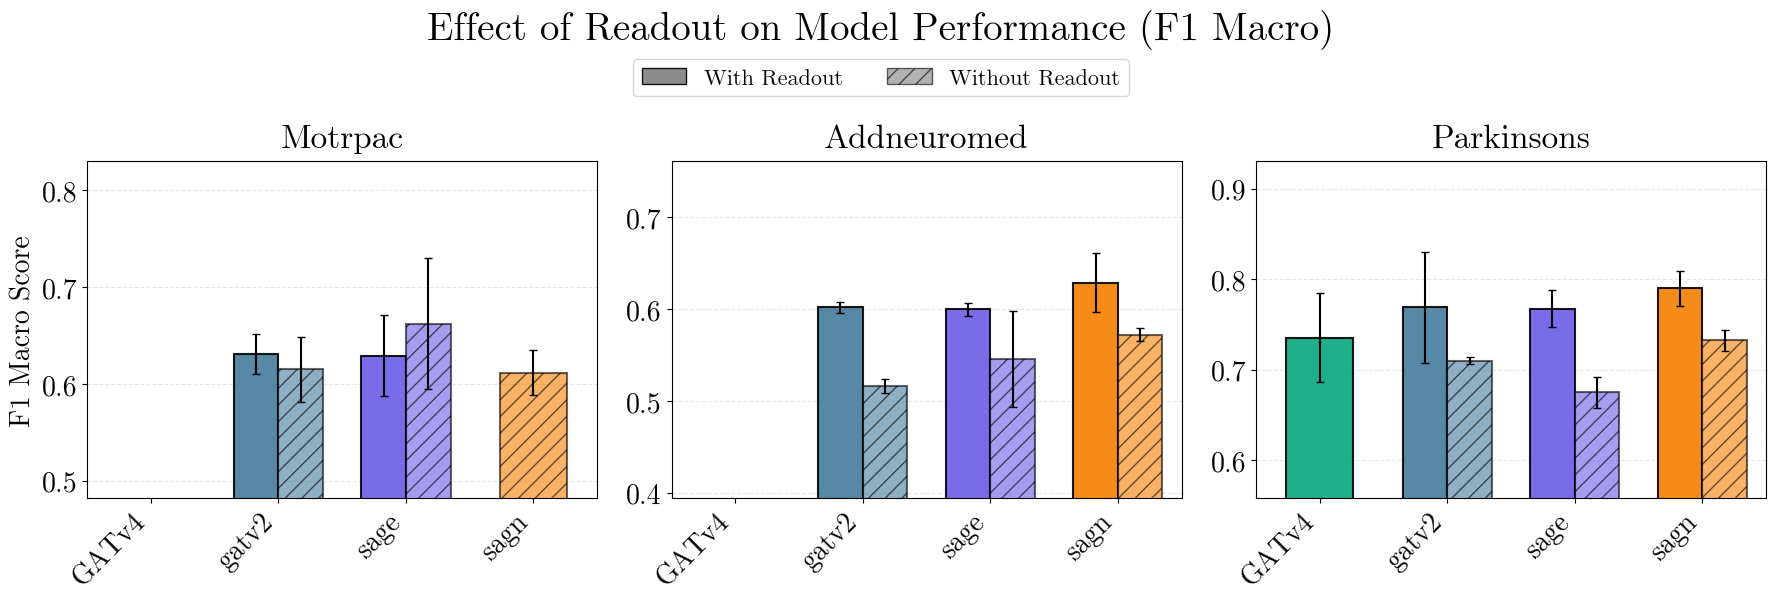


Effect of Readout on Model Performance:

GATv4:
  motrpac:
    With Readout: No data
    Without Readout: No data
  addneuromed:
    With Readout: No data
    Without Readout: No data
  parkinsons:
    With Readout: 0.7353 ± 0.0491
    Without Readout: No data

gatv2:
  motrpac:
    With Readout: 0.6307 ± 0.0207
    Without Readout: 0.6150 ± 0.0331
  addneuromed:
    With Readout: 0.6020 ± 0.0059
    Without Readout: 0.5161 ± 0.0077
  parkinsons:
    With Readout: 0.7692 ± 0.0611
    Without Readout: 0.7099 ± 0.0037

sage:
  motrpac:
    With Readout: 0.6292 ± 0.0420
    Without Readout: 0.6622 ± 0.0679
  addneuromed:
    With Readout: 0.5998 ± 0.0074
    Without Readout: 0.5460 ± 0.0521
  parkinsons:
    With Readout: 0.7675 ± 0.0205
    Without Readout: 0.6750 ± 0.0169

sagn:
  motrpac:
    With Readout: No data
    Without Readout: 0.6115 ± 0.0232
  addneuromed:
    With Readout: 0.6289 ± 0.0321
    Without Readout: 0.5721 ± 0.0070
  parkinsons:
    With Readout: 0.7901 ± 0.0192
  

In [51]:
# ------------------------------------------------------------------
# Plot: Effect of Readout on Model Performance (F1 Macro)
# Compares best performance WITH readout vs WITHOUT readout for each model
# ------------------------------------------------------------------
# Set font to CMU Serif
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['CMU Serif']

# Column definitions
metric_col = "summary.best_test/f1_macro"
metric_std_col = f"{metric_col}_std"
data_name_col = "dataset.loader.parameters.data_name"
method_col = "model.model_name"
readout_col = "model.readout.readout_name"

# Helper function to decode serialized values
def _decode_val(x):
    """Decode serialized values like "__val__:'sagn'" -> "sagn"."""
    if isinstance(x, str):
        if x == "__NaN__":
            return np.nan
        if x.startswith("__val__:"):
            inner = x[len("__val__:"):]
            # Strip simple quotes if present
            if inner.startswith("'") and inner.endswith("'"):
                return inner[1:-1]
            # Try to literal-eval numbers / booleans
            try:
                return ast.literal_eval(inner)
            except Exception:
                return inner
    return x

# Load aggregated data
df_plot = aggregated_df.copy()

# Decode serialized values for the grouping columns
for col in [data_name_col, method_col, readout_col]:
    if col in df_plot.columns:
        df_plot[col] = df_plot[col].apply(_decode_val)

# Ensure metrics are numeric
df_plot[metric_col] = pd.to_numeric(df_plot[metric_col], errors="coerce")
df_plot[metric_std_col] = pd.to_numeric(df_plot[metric_std_col], errors="coerce")

# Filter to valid data and the three datasets
df_plot = df_plot.dropna(subset=[data_name_col, method_col, readout_col, metric_col])
df_plot = df_plot[df_plot[data_name_col].isin(["motrpac", "addneuromed", "parkinsons"])]

# Get all unique models and datasets
# Exclude MLP since it doesn't have a readout option (no comparison to show)
all_models = sorted([m for m in df_plot[method_col].dropna().unique().tolist() if m.lower() != 'mlp'])
datasets = ["motrpac", "addneuromed", "parkinsons"]  # Keep consistent order
readout_types = ["OmicsReadOut", "NoReadOut"]  # With readout, Without readout

# For each model-dataset-readout combination, find the best performance
plot_data = {}
for model in all_models:
    plot_data[model] = {}
    for dataset in datasets:
        plot_data[model][dataset] = {}
        for readout in readout_types:
            # Filter for this model-dataset-readout combination
            subset = df_plot[
                (df_plot[method_col] == model) &
                (df_plot[data_name_col] == dataset) &
                (df_plot[readout_col] == readout)
            ]
            
            if len(subset) > 0:
                # Find the best performance for this combination
                best_idx = subset[metric_col].idxmax()
                plot_data[model][dataset][readout] = {
                    'mean': subset.loc[best_idx, metric_col],
                    'std': subset.loc[best_idx, metric_std_col]
                }
            else:
                plot_data[model][dataset][readout] = {'mean': np.nan, 'std': np.nan}

# Use the shared color mapping
if 'shared_model_colors_dict' not in globals():
    raise ValueError("shared_model_colors_dict not found. Please run the color mapping cell first.")

# Calculate min and max y-values per dataset (each subplot gets its own y-axis)
dataset_ylims = {}
for dataset in datasets:
    vals_with_std = []
    for model in all_models:
        for readout in readout_types:
            data = plot_data[model][dataset][readout]
            if not np.isnan(data['mean']):
                std_val = data['std'] if not np.isnan(data['std']) else 0
                vals_with_std.append(data['mean'] - std_val)
                vals_with_std.append(data['mean'] + std_val)
    if vals_with_std:
        dataset_ylims[dataset] = (min(vals_with_std) - 0.1, max(vals_with_std) + 0.1)
    else:
        dataset_ylims[dataset] = (0, 1)

# Create the subplot grid: 1 row x 3 columns (datasets)
fig, axes = plt.subplots(1, len(datasets), figsize=(18, 6))
fig.suptitle('Effect of Readout on Model Performance (F1 Macro)', 
             fontsize=28, fontweight='bold', y=0.995)

# If only one dataset, axes will be 1D, so make it 2D
if len(datasets) == 1:
    axes = axes.reshape(1, -1)
else:
    axes = axes.reshape(1, -1)

# Readout labels and hatching for visual distinction
readout_labels = {"OmicsReadOut": "With Readout", "NoReadOut": "Without Readout"}
readout_hatches = {"OmicsReadOut": "", "NoReadOut": "//"}

# Plot each subplot (one per dataset)
for j, dataset in enumerate(datasets):
    ax = axes[0, j]
    
    # Create positions for grouped bars
    x_positions = np.arange(len(all_models))
    bar_width = 0.35
    
    # Plot bars for each model - handle models with/without readout options
    for m_idx, model in enumerate(all_models):
        # Check which readout types have data for this model
        has_with_readout = not np.isnan(plot_data[model][dataset]["OmicsReadOut"]['mean'])
        has_without_readout = not np.isnan(plot_data[model][dataset]["NoReadOut"]['mean'])
        
        if has_with_readout and has_without_readout:
            # Model has both readout options - show two bars
            for r_idx, readout in enumerate(readout_types):
                data = plot_data[model][dataset][readout]
                offset = (r_idx - 0.5) * bar_width
                ax.bar(
                    x_positions[m_idx] + offset,
                    data['mean'],
                    yerr=data['std'] if not np.isnan(data['std']) else 0,
                    width=bar_width,
                    capsize=3,
                    color=shared_model_colors_dict[model],
                    edgecolor='black',
                    linewidth=1.5,
                    hatch=readout_hatches[readout],
                    alpha=0.9 if readout == "OmicsReadOut" else 0.6
                )
        elif has_with_readout or has_without_readout:
            # Model has only one readout option (e.g., MLP) - show single centered bar
            readout = "OmicsReadOut" if has_with_readout else "NoReadOut"
            data = plot_data[model][dataset][readout]
            ax.bar(
                x_positions[m_idx],
                data['mean'],
                yerr=data['std'] if not np.isnan(data['std']) else 0,
                width=bar_width * 1.5,  # Slightly wider for single bar
                capsize=3,
                color=shared_model_colors_dict[model],
                edgecolor='black',
                linewidth=1.5,
                hatch=readout_hatches[readout],
                alpha=0.9 if readout == "OmicsReadOut" else 0.6
            )
    
    # Customize subplot
    ax.set_xticks(x_positions)
    ax.set_xticklabels(all_models, rotation=45, ha='right', fontsize=20)
    ax.tick_params(axis='both', labelsize=20)
    ax.set_title(dataset.title(), fontsize=24, fontweight='bold', pad=10)
    # Only show y-axis label on leftmost subplot
    if j == 0:
        ax.set_ylabel('F1 Macro Score', fontsize=20)
    ax.set_xlim(-0.5, len(all_models) - 0.5)  # Adjust x-axis limits after removing MLP
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    ax.set_ylim(dataset_ylims[dataset])

# Add legend at top
handles, labels = axes[0, 0].get_legend_handles_labels()
# Create custom legend handles for readout types
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor='gray', edgecolor='black', hatch='', alpha=0.9, label='With Readout'),
    Patch(facecolor='gray', edgecolor='black', hatch='//', alpha=0.6, label='Without Readout')
]
fig.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 0.93), 
           ncol=2, fontsize=16, frameon=True)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

# Print the values for reference
print("\nEffect of Readout on Model Performance:")
print("=" * 80)
for model in all_models:
    print(f"\n{model}:")
    for dataset in datasets:
        print(f"  {dataset}:")
        for readout in readout_types:
            data = plot_data[model][dataset][readout]
            if not np.isnan(data['mean']):
                print(f"    {readout_labels[readout]}: {data['mean']:.4f} ± {data['std']:.4f}")
            else:
                print(f"    {readout_labels[readout]}: No data")


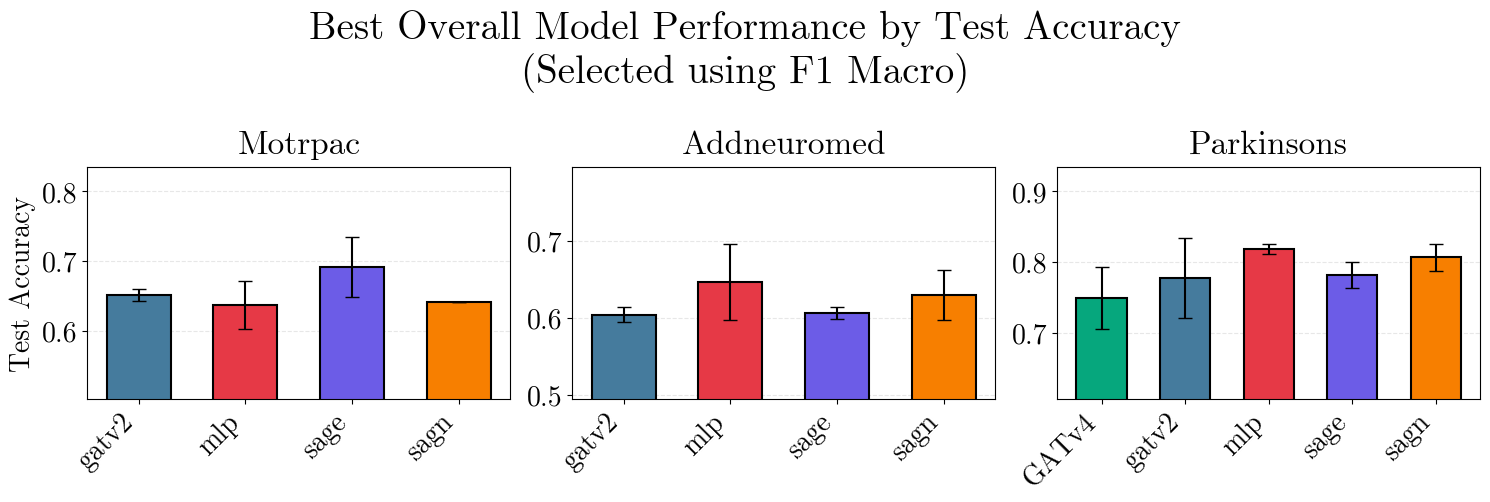


Best Performance by Model and Dataset (Test Accuracy, selected by F1 Macro):

GATv4:
  motrpac: No data
  addneuromed: No data
  parkinsons: 0.7490 ± 0.0434

gatv2:
  motrpac: 0.6517 ± 0.0086
  addneuromed: 0.6042 ± 0.0098
  parkinsons: 0.7778 ± 0.0566

mlp:
  motrpac: 0.6368 ± 0.0345
  addneuromed: 0.6458 ± 0.0491
  parkinsons: 0.8189 ± 0.0071

sage:
  motrpac: 0.6915 ± 0.0431
  addneuromed: 0.6065 ± 0.0080
  parkinsons: 0.7819 ± 0.0189

sagn:
  motrpac: 0.6418 ± 0.0000
  addneuromed: 0.6296 ± 0.0321
  parkinsons: 0.8066 ± 0.0189


In [48]:
# ------------------------------------------------------------------
# Plot: Best Overall Model Performance by Test Accuracy
# (Selected using F1 Macro, plotted using Accuracy)
# ------------------------------------------------------------------
# Set font to CMU Serif
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['CMU Serif']

# Read from aggregated_results.csv and filter for each dataset and model
# Rows: Models (from model.model_name)
# Columns: Datasets
# Each subplot: Best performance for that model-dataset combination
# Use F1 Macro to select best runs, but plot Accuracy
selection_metric_col = "summary.best_test/f1_macro"  # Use this to select best runs
plot_metric_col = "summary.best_test/accuracy"  # Plot this metric
plot_metric_std_col = f"{plot_metric_col}_std"
data_name_col = "dataset.loader.parameters.data_name"
method_col = "model.model_name"

# Helper function to decode serialized values
def _decode_val(x):
    """Decode serialized values like "__val__:'sagn'" -> "sagn"."""
    if isinstance(x, str):
        if x == "__NaN__":
            return np.nan
        if x.startswith("__val__:"):
            inner = x[len("__val__:"):]
            # Strip simple quotes if present
            if inner.startswith("'") and inner.endswith("'"):
                return inner[1:-1]
            # Try to literal-eval numbers / booleans
            try:
                return ast.literal_eval(inner)
            except Exception:
                return inner
    return x

# Load aggregated data
df_plot = aggregated_df.copy()

# Decode serialized values for the grouping columns
for col in [data_name_col, method_col]:
    if col in df_plot.columns:
        df_plot[col] = df_plot[col].apply(_decode_val)

# Ensure metrics are numeric
df_plot[selection_metric_col] = pd.to_numeric(df_plot[selection_metric_col], errors="coerce")
df_plot[plot_metric_col] = pd.to_numeric(df_plot[plot_metric_col], errors="coerce")
df_plot[plot_metric_std_col] = pd.to_numeric(df_plot[plot_metric_std_col], errors="coerce")

# Filter to valid data and the three datasets
df_plot = df_plot.dropna(subset=[data_name_col, method_col, selection_metric_col])
df_plot = df_plot[df_plot[data_name_col].isin(["motrpac", "addneuromed", "parkinsons"])]

# Get all unique models and datasets
all_models = sorted(df_plot[method_col].dropna().unique().tolist())
datasets = ["motrpac", "addneuromed", "parkinsons"]  # Keep consistent order

# For each model-dataset combination, find the best performance using F1 Macro
# Then extract the Accuracy values for those best runs
plot_data = {}
for model in all_models:
    plot_data[model] = {}
    for dataset in datasets:
        # Filter for this model-dataset combination
        subset = df_plot[
            (df_plot[method_col] == model) &
            (df_plot[data_name_col] == dataset)
        ]
        
        if len(subset) > 0:
            # Find the best performance using F1 Macro for selection
            best_idx = subset[selection_metric_col].idxmax()
            # Extract Accuracy values from the same best run
            plot_data[model][dataset] = {
                'mean': subset.loc[best_idx, plot_metric_col],
                'std': subset.loc[best_idx, plot_metric_std_col]
            }
        else:
            plot_data[model][dataset] = {'mean': np.nan, 'std': np.nan}

# Use the shared color mapping created earlier
# This ensures consistent colors across all plots
if 'shared_model_colors_dict' not in globals():
    raise ValueError("shared_model_colors_dict not found. Please run the color mapping cell first.")
method_colors_dict = shared_model_colors_dict  # Use the shared color mapping

# Calculate min and max y-values per dataset (each subplot gets its own y-axis)
dataset_ylims = {}
for dataset in datasets:
    vals_with_std = []
    for model in all_models:
        data = plot_data[model][dataset]
        if not np.isnan(data['mean']):
            std_val = data['std'] if not np.isnan(data['std']) else 0
            vals_with_std.append(data['mean'] - std_val)
            vals_with_std.append(data['mean'] + std_val)
    if vals_with_std:
        dataset_ylims[dataset] = (min(vals_with_std) - 0.1, max(vals_with_std) + 0.1)
    else:
        dataset_ylims[dataset] = (0, 1)

# Create the subplot grid: 1 row x 3 columns (datasets), all models together
fig, axes = plt.subplots(1, len(datasets), figsize=(15, 5))
fig.suptitle('Best Overall Model Performance by Test Accuracy\n(Selected using F1 Macro)', 
             fontsize=28, fontweight='bold', y=0.995)

# If only one dataset, axes will be 1D, so make it 2D
if len(datasets) == 1:
    axes = axes.reshape(1, -1)
else:
    axes = axes.reshape(1, -1)

# Plot each subplot (one per dataset)
for j, dataset in enumerate(datasets):
    ax = axes[0, j]
    
    # Collect data for all models for this dataset
    means = []
    stds = []
    labels = []
    colors = []
    
    for model in all_models:
        data = plot_data[model][dataset]
        mean_val = data['mean']
        std_val = data['std']
        
        if not np.isnan(mean_val):
            means.append(mean_val)
            stds.append(std_val)
            labels.append(model)
            colors.append(method_colors_dict[model])
    
    # Create positions for bars
    if len(means) > 0:
        x_positions = np.arange(len(means))
        bar_width = 0.6  # Fixed bar width
        
        # Create grouped bars for all models
        bars = ax.bar(
            x_positions,
            means,
            yerr=stds,
            width=bar_width,
            capsize=5,
            color=colors,
            edgecolor='black',
            linewidth=1.5
        )
        
        # Customize subplot
        ax.set_xticks(x_positions)
        ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=20)
    else:
        # No data for this dataset
        ax.set_xticks([])
    
    ax.tick_params(axis='both', labelsize=20)
    ax.set_title(dataset.title(), fontsize=24, fontweight='bold', pad=10)
    # Only show y-axis label on leftmost subplot
    if j == 0:
        ax.set_ylabel('Test Accuracy', fontsize=20)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    ax.set_ylim(dataset_ylims[dataset])

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

# Print the values for reference
print("\nBest Performance by Model and Dataset (Test Accuracy, selected by F1 Macro):")
print("=" * 80)
for model in all_models:
    print(f"\n{model}:")
    for dataset in datasets:
        data = plot_data[model][dataset]
        if not np.isnan(data['mean']):
            print(f"  {dataset}: {data['mean']:.4f} ± {data['std']:.4f}")
        else:
            print(f"  {dataset}: No data")


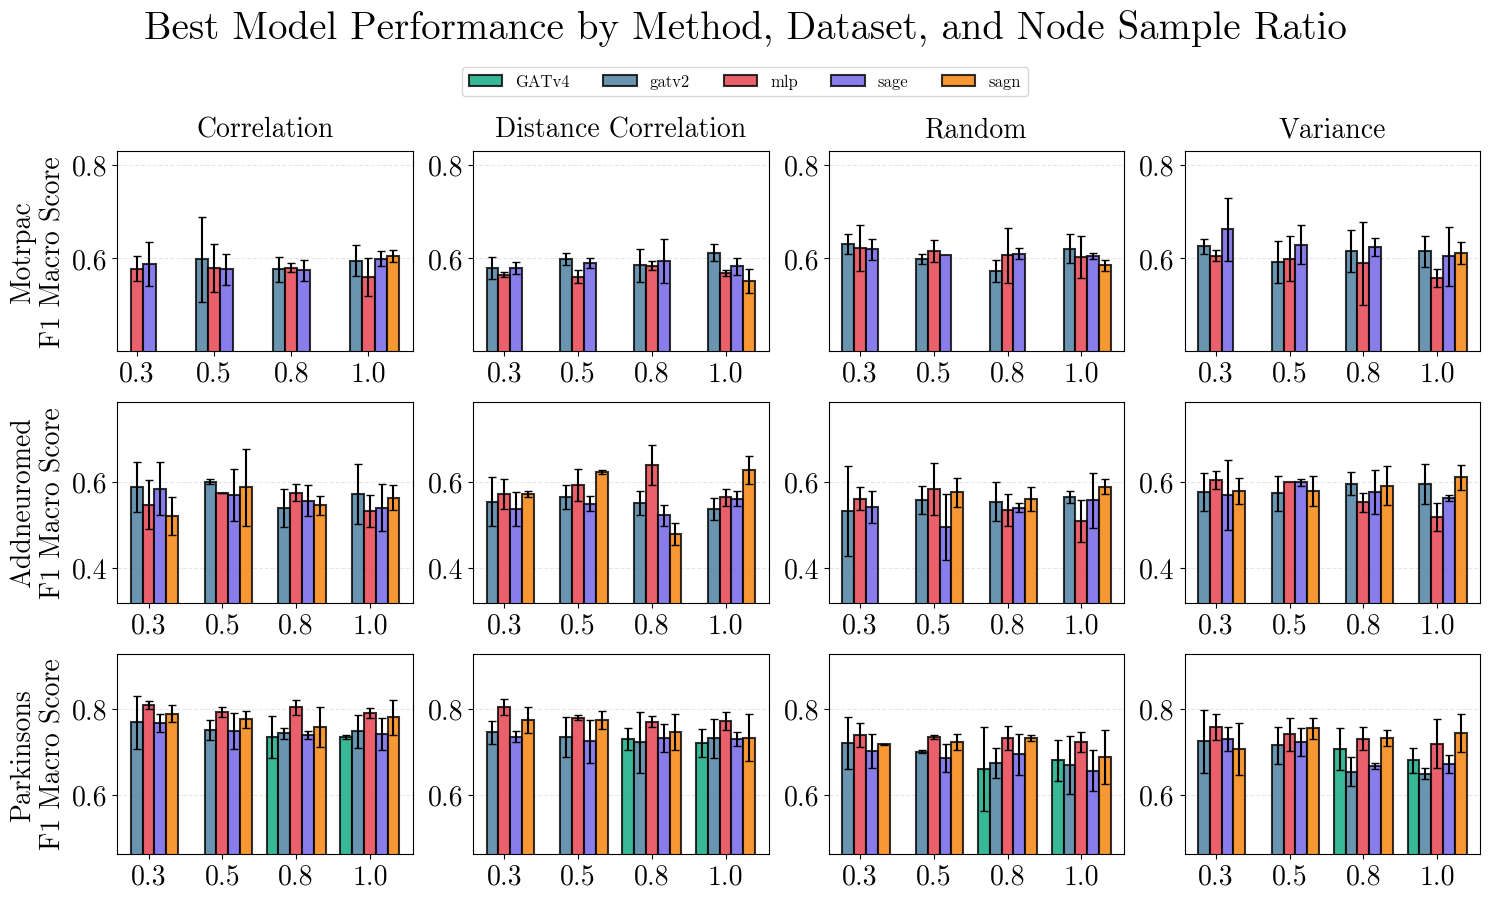


Data Summary:

correlation:
  motrpac:
    0.3:
      GATv4: No data
      gatv2: No data
      mlp: 0.5783 ± 0.0276
      sage: 0.5879 ± 0.0469
      sagn: No data
    0.5:
      GATv4: No data
      gatv2: 0.5978 ± 0.0910
      mlp: 0.5791 ± 0.0515
      sage: 0.5765 ± 0.0329
      sagn: No data
    0.8:
      GATv4: No data
      gatv2: 0.5768 ± 0.0271
      mlp: 0.5800 ± 0.0097
      sage: 0.5750 ± 0.0223
      sagn: No data
    1.0:
      GATv4: No data
      gatv2: 0.5955 ± 0.0338
      mlp: 0.5607 ± 0.0407
      sage: 0.5996 ± 0.0159
      sagn: 0.6059 ± 0.0126
  addneuromed:
    0.3:
      GATv4: No data
      gatv2: 0.5893 ± 0.0580
      mlp: 0.5481 ± 0.0564
      sage: 0.5857 ± 0.0619
      sagn: 0.5221 ± 0.0444
    0.5:
      GATv4: No data
      gatv2: 0.6020 ± 0.0059
      mlp: 0.5751 ± 0.0002
      sage: 0.5705 ± 0.0604
      sagn: 0.5888 ± 0.0894
    0.8:
      GATv4: No data
      gatv2: 0.5399 ± 0.0449
      mlp: 0.5758 ± 0.0194
      sage: 0.5569 ± 0.0362
      sagn:

In [49]:
# ------------------------------------------------------------------
# Plot: Best Model Performance by Method, Dataset, and Node Sample Ratio
# ------------------------------------------------------------------
# Set font to CMU Serif (if not already set)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['CMU Serif']

# Extract data from aggregated_df directly
# Rows: datasets
# Columns: methods (from dataset.loader.parameters.method)
# Each subplot: For each node_sample_ratio, show bars for all models
metric_col = "summary.best_test/f1_macro"
metric_std_col = f"{metric_col}_std"
data_name_col = "dataset.loader.parameters.data_name"
method_col = "dataset.loader.parameters.method"  # Rows: sampling methods
model_col = "model.model_name"  # Bars: models
node_sample_ratio_col = "dataset.loader.parameters.node_sample_ratio"

# Helper function to decode serialized values
def _decode_val(x):
    """Decode serialized values like "__val__:'sagn'" -> "sagn"."""
    if isinstance(x, str):
        if x == "__NaN__":
            return np.nan
        if x.startswith("__val__:"):
            inner = x[len("__val__:"):]
            # Strip simple quotes if present
            if inner.startswith("'") and inner.endswith("'"):
                return inner[1:-1]
            # Try to literal-eval numbers / booleans
            try:
                return ast.literal_eval(inner)
            except Exception:
                return inner
    return x

# Load aggregated data
df_plot2 = aggregated_df.copy()

# Decode serialized values for the grouping columns
for col in [data_name_col, method_col, model_col, node_sample_ratio_col]:
    if col in df_plot2.columns:
        df_plot2[col] = df_plot2[col].apply(_decode_val)

# Ensure metrics are numeric
df_plot2[metric_col] = pd.to_numeric(df_plot2[metric_col], errors="coerce")
df_plot2[metric_std_col] = pd.to_numeric(df_plot2[metric_std_col], errors="coerce")

# Filter to valid data and the three datasets
df_plot2 = df_plot2.dropna(subset=[data_name_col, method_col, model_col, node_sample_ratio_col, metric_col])
df_plot2 = df_plot2[df_plot2[data_name_col].isin(["motrpac", "addneuromed", "parkinsons"])]

# Get all unique methods (columns), models (bars), datasets (rows), and ratios (groups)
all_methods = sorted(df_plot2[method_col].dropna().unique().tolist())
all_models = sorted(df_plot2[model_col].dropna().unique().tolist())
datasets = ["motrpac", "addneuromed", "parkinsons"]  # Keep consistent order
all_ratios = sorted(df_plot2[node_sample_ratio_col].dropna().unique().tolist())

# Use the shared color mapping created earlier
# This ensures consistent colors across all plots
if 'shared_model_colors_dict' not in globals():
    raise ValueError("shared_model_colors_dict not found. Please run the color mapping cell first.")
model_colors = shared_model_colors_dict  # Use the shared color mapping

# Extract mean and std values for each method-dataset-ratio-model combination
# For each method-dataset-ratio-model, find the best performance
plot_data = {}
for method in all_methods:
    plot_data[method] = {}
    for dataset in datasets:
        plot_data[method][dataset] = {}
        for ratio in all_ratios:
            plot_data[method][dataset][ratio] = {}
            for model in all_models:
                # Filter for this method-dataset-ratio-model combination
                subset = df_plot2[
                    (df_plot2[method_col] == method) &
                    (df_plot2[data_name_col] == dataset) &
                    (df_plot2[node_sample_ratio_col] == ratio) &
                    (df_plot2[model_col] == model)
                ]
                
                if len(subset) > 0:
                    # Find the best performance for this combination
                    best_idx = subset[metric_col].idxmax()
                    plot_data[method][dataset][ratio][model] = {
                        'mean': subset.loc[best_idx, metric_col],
                        'std': subset.loc[best_idx, metric_std_col]
                    }
                else:
                    plot_data[method][dataset][ratio][model] = {'mean': np.nan, 'std': np.nan}

# Create the subplot grid: 3 rows (datasets) x 4 columns (methods)
fig, axes = plt.subplots(len(datasets), len(all_methods), figsize=(15, 9))
fig.suptitle('Best Model Performance by Method, Dataset, and Node Sample Ratio', 
             fontsize=28, fontweight='bold', y=0.995)

# If only one dataset, axes will be 1D, so make it 2D
if len(datasets) == 1:
    axes = axes.reshape(1, -1)
if len(all_methods) == 1:
    axes = axes.reshape(-1, 1)

# First, calculate the min and max y-values for each dataset (row) across all methods
# This ensures all subplots in the same row have the same y-axis scale
dataset_min_vals = {}
dataset_max_vals = {}
for i, dataset in enumerate(datasets):
    min_val = float('inf')
    max_val = 0.3  # Start with minimum
    for j, method in enumerate(all_methods):
        method_data = plot_data[method][dataset]
        for ratio in all_ratios:
            for model in all_models:
                if model in method_data[ratio]:
                    mean_val = method_data[ratio][model]['mean']
                    std_val = method_data[ratio][model]['std']
                    if not np.isnan(mean_val):
                        # Consider mean - std for minimum (error bars can go below)
                        min_val = min(min_val, mean_val - (std_val if not np.isnan(std_val) else 0))
                        # Consider mean + std for maximum (error bars can go above)
                        max_val = max(max_val, mean_val + (std_val if not np.isnan(std_val) else 0))
    # Add 0.1 padding below min and above max
    if min_val == float('inf'):
        min_val = 0.3
    dataset_min_vals[dataset] = max(0.0, min_val - 0.1)
    dataset_max_vals[dataset] = max_val + 0.1

# Plot each subplot
# Each subplot shows: for each node_sample_ratio, bars for all models
bar_width = 0.8 / len(all_models)  # Width of each bar group
group_width = 0.8  # Total width of each group

for i, dataset in enumerate(datasets):
    for j, method in enumerate(all_methods):
        ax = axes[i, j]
        
        # Get data for this method-dataset combination
        method_data = plot_data[method][dataset]
        
        # Create positions for grouped bars
        x_groups = np.arange(len(all_ratios))  # Positions for each ratio group
        x_positions = {}  # Store x positions for each model within each group
        
        # Calculate offset for each model to center the group
        for model_idx, model in enumerate(all_models):
            offset = (model_idx - (len(all_models) - 1) / 2) * bar_width
            x_positions[model] = x_groups + offset
        
        # Plot bars for each model, grouped by ratio
        for model in all_models:
            means = []
            stds = []
            for ratio in all_ratios:
                if model in method_data[ratio]:
                    means.append(method_data[ratio][model]['mean'])
                    stds.append(method_data[ratio][model]['std'])
                else:
                    means.append(np.nan)
                    stds.append(np.nan)
            
            bars = ax.bar(
                x_positions[model],
                means,
                yerr=stds,
                width=bar_width,
                capsize=3,
                label=model,
                color=model_colors[model],
                edgecolor='black',
                linewidth=1.5,
                alpha=0.8
            )
        
        # Customize subplot
        ax.set_xticks(x_groups)
        ax.set_xticklabels(all_ratios, rotation=0, fontsize=20)
        ax.tick_params(axis='both', labelsize=20)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
        # Set y-axis limits: same min/max for all subplots in the same row (dataset)
        ax.set_ylim(dataset_min_vals[dataset], dataset_max_vals[dataset])
        
        # Set title: method name on top, dataset name on left
        if i == 0:  # Top row: method names
            ax.set_title(method.replace('_', ' ').title(), fontsize=20, fontweight='bold', pad=10)
        if j == 0:  # Left column: dataset names and y-axis label
            ax.set_ylabel(f'{dataset.title()}\nF1 Macro Score', fontsize=20, fontweight='bold')

# Collect handles and labels from the first subplot (all subplots have the same legend)
handles, labels = axes[0, 0].get_legend_handles_labels()

# Add legend above the plots, next to the title
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.94), 
           ncol=len(all_models), fontsize=12, frameon=True)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Print summary
print("\nData Summary:")
print("=" * 80)
for method in all_methods:
    print(f"\n{method}:")
    for dataset in datasets:
        print(f"  {dataset}:")
        for ratio in all_ratios:
            print(f"    {ratio}:")
            for model in all_models:
                if model in plot_data[method][dataset][ratio]:
                    data = plot_data[method][dataset][ratio][model]
                    if not np.isnan(data['mean']):
                        print(f"      {model}: {data['mean']:.4f} ± {data['std']:.4f}")
                    else:
                        print(f"      {model}: No data")
                else:
                    print(f"      {model}: No data")


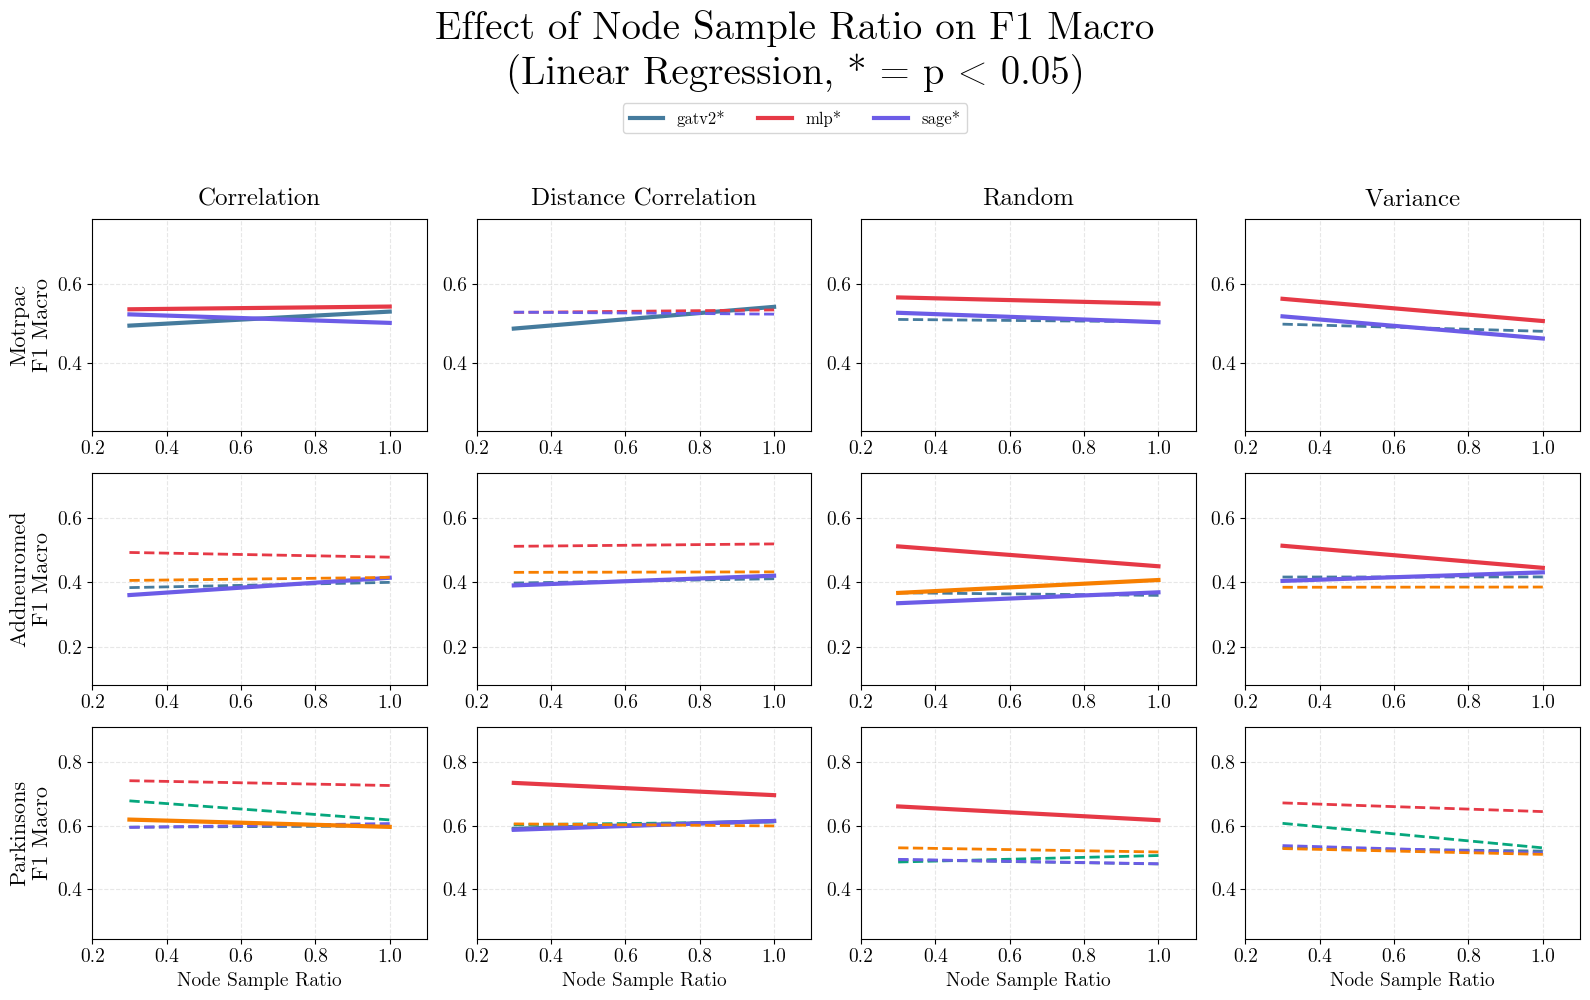


Summary: Statistically Significant Relationships (p < 0.05)
Dataset         Method                    Model           Slope       R²      p-value
----------------------------------------------------------------------------------------------------
motrpac         correlation               gatv2         +0.0504↑   0.0472   4.6528e-04
motrpac         correlation               mlp           +0.0098↑   0.0288   1.8653e-02
motrpac         correlation               sage          -0.0306↓   0.0489   1.2317e-05
motrpac         distance_correlation      gatv2         +0.0781↑   0.1656   4.1236e-14
motrpac         random                    mlp           -0.0223↓   0.0494   1.9938e-03
motrpac         random                    sage          -0.0339↓   0.0182   8.1392e-03
motrpac         variance                  mlp           -0.0799↓   0.2517   1.2441e-13
motrpac         variance                  sage          -0.0796↓   0.0713   1.1326e-07
addneuromed     correlation               sage          

In [52]:
# ------------------------------------------------------------------
# Plot: Linear Regression of Node Sample Ratio vs F1 Macro
# Shows if there's a statistically significant relationship between
# node_sample_ratio and f1_macro for each model, dataset, and method
# ------------------------------------------------------------------
from scipy import stats

# Set font to CMU Serif
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['CMU Serif']

# Column definitions
metric_col = "summary.best_test/f1_macro"
metric_std_col = f"{metric_col}_std"
data_name_col = "dataset.loader.parameters.data_name"
method_col = "dataset.loader.parameters.method"
model_col = "model.model_name"
node_sample_ratio_col = "dataset.loader.parameters.node_sample_ratio"

# Helper function to decode serialized values
def _decode_val(x):
    """Decode serialized values like "__val__:'sagn'" -> "sagn"."""
    if isinstance(x, str):
        if x == "__NaN__":
            return np.nan
        if x.startswith("__val__:"):
            inner = x[len("__val__:"):]
            if inner.startswith("'") and inner.endswith("'"):
                return inner[1:-1]
            try:
                return ast.literal_eval(inner)
            except Exception:
                return inner
    return x

# Load aggregated data
df_reg = aggregated_df.copy()

# Decode serialized values
for col in [data_name_col, method_col, model_col, node_sample_ratio_col]:
    if col in df_reg.columns:
        df_reg[col] = df_reg[col].apply(_decode_val)

# Ensure metrics are numeric
df_reg[metric_col] = pd.to_numeric(df_reg[metric_col], errors="coerce")
df_reg[node_sample_ratio_col] = pd.to_numeric(df_reg[node_sample_ratio_col], errors="coerce")

# Filter to valid data and the three datasets
df_reg = df_reg.dropna(subset=[data_name_col, method_col, model_col, node_sample_ratio_col, metric_col])
df_reg = df_reg[df_reg[data_name_col].isin(["motrpac", "addneuromed", "parkinsons"])]

# Get unique values
all_methods = sorted(df_reg[method_col].dropna().unique().tolist())
all_models = sorted(df_reg[model_col].dropna().unique().tolist())
datasets = ["motrpac", "addneuromed", "parkinsons"]

# For each dataset-method-model combination, fit linear regression
regression_results = {}
for dataset in datasets:
    regression_results[dataset] = {}
    for method in all_methods:
        regression_results[dataset][method] = {}
        for model in all_models:
            # Get data for this combination
            subset = df_reg[
                (df_reg[data_name_col] == dataset) &
                (df_reg[method_col] == method) &
                (df_reg[model_col] == model)
            ]
            
            if len(subset) >= 2:  # Need at least 2 points for regression
                x = subset[node_sample_ratio_col].values
                y = subset[metric_col].values
                
                # Check if x values have variation (can't regress if all x are identical)
                if np.amax(x) == np.amin(x):
                    regression_results[dataset][method][model] = None
                    continue
                
                # Fit linear regression
                slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
                
                regression_results[dataset][method][model] = {
                    'slope': slope,
                    'intercept': intercept,
                    'r_squared': r_value**2,
                    'p_value': p_value,
                    'significant': p_value < 0.05,
                    'x': x,
                    'y': y
                }
            else:
                regression_results[dataset][method][model] = None

# Use the shared color mapping
if 'shared_model_colors_dict' not in globals():
    raise ValueError("shared_model_colors_dict not found. Please run the color mapping cell first.")

# Create the subplot grid: 3 rows (datasets) x N columns (methods)
fig, axes = plt.subplots(len(datasets), len(all_methods), figsize=(16, 10))
fig.suptitle('Effect of Node Sample Ratio on F1 Macro\n(Linear Regression, * = p < 0.05)', 
             fontsize=28, fontweight='bold', y=0.995)

# Handle 1D axes
if len(datasets) == 1:
    axes = axes.reshape(1, -1)
if len(all_methods) == 1:
    axes = axes.reshape(-1, 1)

# Calculate y-axis limits per row (dataset)
dataset_ylims = {}
for dataset in datasets:
    all_y = []
    for method in all_methods:
        for model in all_models:
            result = regression_results[dataset][method][model]
            if result is not None:
                all_y.extend(result['y'])
    if all_y:
        dataset_ylims[dataset] = (min(all_y) - 0.1, max(all_y) + 0.1)
    else:
        dataset_ylims[dataset] = (0, 1)

# Plot each subplot
for i, dataset in enumerate(datasets):
    for j, method in enumerate(all_methods):
        ax = axes[i, j]
        
        # Plot each model
        for model in all_models:
            result = regression_results[dataset][method][model]
            
            if result is not None:
                x = result['x']
                y = result['y']
                slope = result['slope']
                intercept = result['intercept']
                significant = result['significant']
                
                # Plot regression line (no scatter points for cleaner visualization)
                x_line = np.linspace(0.3, 1.0, 100)  # Full range of ratios
                y_line = slope * x_line + intercept
                
                # Add star to label if significant
                label = f"{model}*" if significant else model
                linestyle = '-' if significant else '--'
                linewidth = 3 if significant else 2
                
                ax.plot(x_line, y_line, color=shared_model_colors_dict[model], 
                       linestyle=linestyle, linewidth=linewidth, label=label)
        
        # Customize subplot
        ax.tick_params(axis='both', labelsize=14)
        ax.grid(axis='both', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
        ax.set_ylim(dataset_ylims[dataset])
        ax.set_xlim(0.2, 1.1)
        
        # Set titles
        if i == 0:  # Top row: method names
            ax.set_title(method.replace('_', ' ').title(), fontsize=18, fontweight='bold', pad=10)
        if j == 0:  # Left column: dataset names and y-label
            ax.set_ylabel(f'{dataset.title()}\nF1 Macro', fontsize=16, fontweight='bold')
        
        # X-axis label on bottom row only
        if i == len(datasets) - 1:
            ax.set_xlabel('Node Sample Ratio', fontsize=14)

# Collect legend handles from first subplot with data
handles, labels = [], []
for ax in axes.flat:
    h, l = ax.get_legend_handles_labels()
    if h:
        handles, labels = h, l
        break

# Add legend at top (deduplicate labels)
seen = set()
unique_handles, unique_labels = [], []
for h, l in zip(handles, labels):
    base_label = l.rstrip('*')
    if base_label not in seen:
        seen.add(base_label)
        unique_handles.append(h)
        unique_labels.append(l)

fig.legend(unique_handles, unique_labels, loc='upper center', 
           bbox_to_anchor=(0.5, 0.91), ncol=len(all_models), fontsize=12, frameon=True)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# Print summary of significant relationships
print("\n" + "=" * 100)
print("Summary: Statistically Significant Relationships (p < 0.05)")
print("=" * 100)
print(f"{'Dataset':<15} {'Method':<25} {'Model':<10} {'Slope':>10} {'R²':>8} {'p-value':>12}")
print("-" * 100)

for dataset in datasets:
    for method in all_methods:
        for model in all_models:
            result = regression_results[dataset][method][model]
            if result is not None and result['significant']:
                direction = "↑" if result['slope'] > 0 else "↓"
                print(f"{dataset:<15} {method:<25} {model:<10} {result['slope']:>+10.4f}{direction} {result['r_squared']:>8.4f} {result['p_value']:>12.4e}")

print("\n" + "=" * 100)
print("All Regression Results")
print("=" * 100)
for dataset in datasets:
    print(f"\n{dataset.upper()}:")
    for method in all_methods:
        print(f"  {method}:")
        for model in all_models:
            result = regression_results[dataset][method][model]
            if result is not None:
                sig = "*" if result['significant'] else ""
                print(f"    {model}: slope={result['slope']:+.4f}, R²={result['r_squared']:.4f}, p={result['p_value']:.4e}{sig}")
            else:
                print(f"    {model}: Insufficient data")
